<a href="https://colab.research.google.com/github/j-claudinei-f/j-claudinei-f/blob/main/MaxMinDerivadasParciais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Derivadas Parciais e Aplicações**

José Claudinei Ferrerira

Universidade Federal de Alfenas

#**Uma breve revisão**

Consideramos neste curso questões ligadas a funções de duas ou três varáveis. Essas questões estão ligadas a gráficos, áreas regiões e volumes de sólidos.



**Um exemplo de revisão**

A função $f(x,y)=y^2-y^4-x^2$ é uma função contínua, que tem como domínio todo o plano $\mathbb{R}^2$, e possui derivadas de todas as ordens.

Em particular, temos as funções $$\frac{\partial f(x,y)}{\partial y}=-2x,\qquad \frac{\partial f(x,y)}{\partial y}=2y-4y^3,$$ que são derivadas parciais de primeira ordem de $f(x,y)$.

Podemos agora calcular valores dessas funções usando suas expressões e escolhendo valores para $x$ e $y$. Por exemplo, $$f(1,2)=2^2-2^4-1^2=-13, \frac{\partial f(0.5,0.75)}{\partial y}=-2\times 0.5=-1,\qquad \frac{\partial f(-0.5,0.75)}{\partial y}=2\times 0.75-4\times 0.75^3=-0.1875$$

In [1]:
#@title Definição da função f(x, y) usando Python.
def f(x, y):
    return y**2 - y**4 - x**2

# Definição das derivadas parciais de primeira ordem.
def df_dx(x, y):
    return -2 * x

def df_dy(x, y):
    return 2 * y - 4 * y**3

f(1,2),df_dx(0.5,0.75), df_dy(-0.5,0.75)   # Chamada da função e das derivadas parcias.
                                               # O retorno é uma lista com valores reais.

(-13, -1.0, -0.1875)

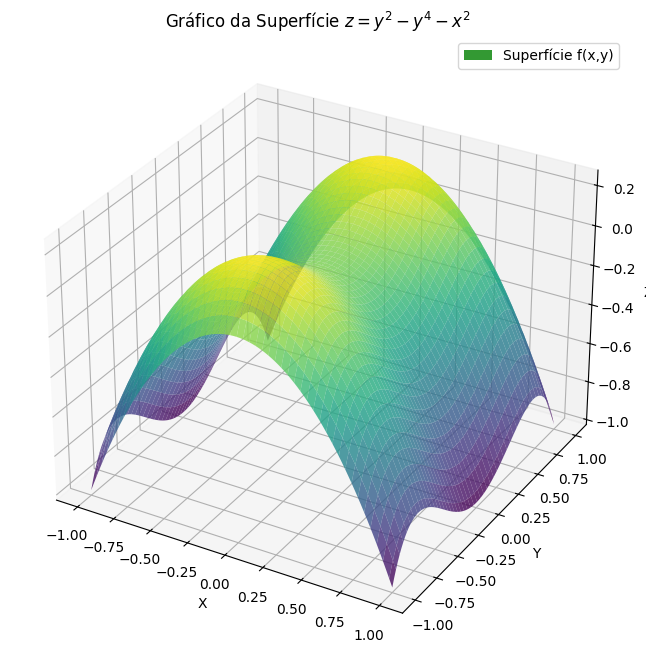

In [4]:
#@title Gráfico da função $f(x,y)$.
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for plotting the surface and plane
x_vals = np.linspace(-1, 1, 100)
y_vals = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x_vals, y_vals)

# Calculate Z for the surface
Z_surface = f(X, Y)

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z_surface, cmap='viridis', alpha=0.8, label='Superfície f(x,y)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Gráfico da Superfície $z=y^2-y^4-x^2$')

# Create dummy artists for legend workaround
surface_proxy = plt.Rectangle((0,0), 1, 1, fc="green", alpha=0.8)
plane_proxy = plt.Rectangle((0,0), 1, 1, fc="blue", alpha=0.5)
point_tangency_proxy = plt.Line2D([0],[0], linestyle="none", c='red', marker = 'o')

ax.legend([surface_proxy],
          ['Superfície f(x,y)'])

plt.show()

Podemos falar na derivada de $f(x,y)$ quando consideramos o vetor gradiente $$\nabla f(x,y)=\left(\frac{\partial f(x,y)}{\partial y},\frac{\partial f(x,y)}{\partial y}\right)=\left(-2x,2y-4y^3\right)=-2(x,y-2y^3).$$

Ainda, o vetor gradiente nos dá a direção em que a função cresce mais, quando seguimos em um trajeto cujo vetor velocidade tem módulo 1.

Nessas condições, por exemplo, no ponto $P=(0.5,0.75)$ a direção em que $f(x,y)$ cresce mais é a do vetor $$\nabla f(0.5,0.75)=(-1,-0.1875).$$

Como $f(x,y)=y^2-y^4-x^2=(1-y^2)y^2-x^2$ é negativa, para $|y|>1$, e $x^2$ e $y^2$ crescem quando $|x|$ e $|y|$ crescem, respectivamente, então $f(x,y)$ possui valor máximo. Podemos determinar algebricamente esse valor máximo obsevando quando $\nabla f(x,y)$ é nulo, no caso, quando $$x=0,\qquad y(1-2y^2)=0$$  que equivale aos pontos $$(0,0),\quad \left(0,\frac{\sqrt{2}}{2}\right),\quad \left(0,-\frac{\sqrt{2}}{2}\right).$$ Ou seja, o maior valor de $f(x,y)$ é $$f\left(0,-\frac{\sqrt{2}}{2}\right)=f\left(0,\frac{\sqrt{2}}{2}\right)=\frac{1}{4}.$$

Como temos o gráfico de $f(x,y)$ acima, vemos que o ponto $(0,0)$ é um ponto de sela.

In [7]:
f(0,0),f(0,np.sqrt(2)/2), f(0,-np.sqrt(2)/2)

(0, np.float64(0.25000000000000006), np.float64(0.25000000000000006))

In [6]:
#@title Definição do vetor $\nabla f(x,y)$ em Python.
import numpy as np
def grad_f(x,y):
  return  np.array([df_dx(x,y),df_dy(x,y)])

grad_f(0,np.sqrt(2)/2)

array([ 0.00000000e+00, -2.22044605e-16])

Outra utilidade do vetor gradiente é na determinação do plano tangente ao gráfico de $f(x,y)$, por um ponto $(x_0,y_0)$ fixado.

Nesse caso, temos a aproximação $$f(x,y)\approx f(x_0,y_0)+\nabla f(x_0,y_0)\cdot (x-x_0,y-y_0),$$ que nos dá o plano tangente ao gráfico como $$T:\, (x,y,z)=(x,y,f(x_0,y_0)+\nabla f(x_0,y_0)\cdot (x-x_0,y-y_0)).$$

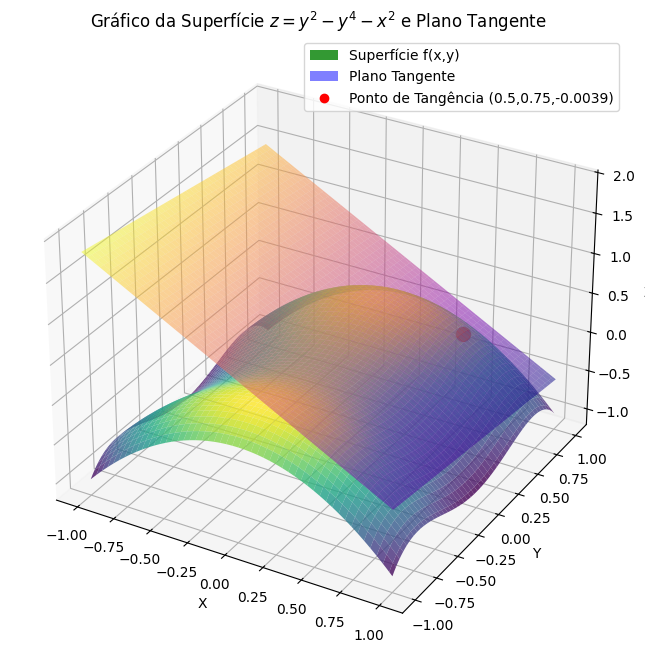

In [ ]:
#@title Gráfico da função $f(x,y)$ e da aproximação do gráfico por plano tangente, no ponto $(0.5,0.75)$.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Point of tangency for the plane
x0, y0 = .5, .75
z0 = f(x0, y0)

# Evaluate partial derivatives at (x0, y0) for the plane
fx0 = df_dx(x0, y0)
fy0 = df_dy(x0, y0)

# Equation of the tangent plane: Z - z0 = fx0*(X - x0) + fy0*(Y - y0)
# Z = z0 + fx0*(X - x0) + fy0*(Y - y0)
def tangent_plane(x, y, x0, y0, z0, fx0, fy0):
    return z0 + fx0 * (x - x0) + fy0 * (y - y0)

# Calculate Z for the tangent plane
Z_plane = tangent_plane(X, Y, x0, y0, z0, fx0, fy0)


# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z_surface, cmap='viridis', alpha=0.8, label='Superfície f(x,y)')

# Plot the tangent plane
ax.plot_surface(X, Y, Z_plane, cmap='plasma', alpha=0.5, label='Plano Tangente')

# Plot the point of tangency for the plane
ax.scatter([x0], [y0], [z0], color='red', s=100, label=f'Ponto de Tangência ({x0},{y0},{z0:.4f})')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Gráfico da Superfície $z=y^2-y^4-x^2$ e Plano Tangente')

# Create dummy artists for legend workaround
surface_proxy = plt.Rectangle((0,0), 1, 1, fc="green", alpha=0.8)
plane_proxy = plt.Rectangle((0,0), 1, 1, fc="blue", alpha=0.5)
point_tangency_proxy = plt.Line2D([0],[0], linestyle="none", c='red', marker = 'o')

ax.legend([surface_proxy, plane_proxy, point_tangency_proxy],
          ['Superfície f(x,y)', 'Plano Tangente', f'Ponto de Tangência ({x0},{y0},{z0:.4f})'])

plt.show()

Por fim, nesse e em outros casos, o valor máximo de $f(x,y)$ poderia ser aproximado numéricamente pelo chamado método dos gradientes, que se resume a caminhar sobre o domínio da função, no caso o plano $xy$, partindo do ponto $(x_0,y_0)$ e dando passos pequenos na direção do vetor gradiente no ponto atingido no passo anterior.

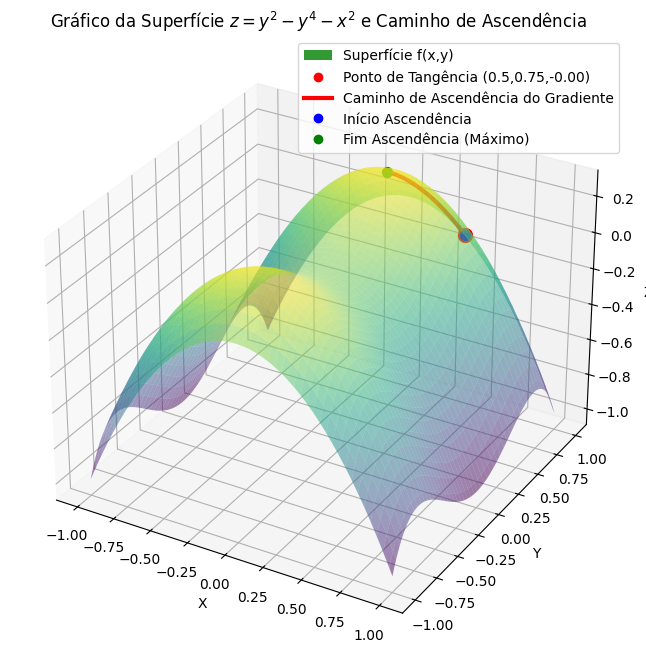

In [20]:
#@title Mátodo dos gradinetes, com início no ponto $(0.5,0.75)$.
def gradient_ascent(start_point, learning_rate, iterations):
    path = [start_point]
    x, y = start_point
    for _ in range(iterations):
        grad_x = df_dx(x, y)
        grad_y = df_dy(x, y)
        x = x + learning_rate * grad_x
        y = y + learning_rate * grad_y
        path.append((x, y))
    return np.array(path)

# Parameters for gradient ascent
start_point_grad = (0.5, 0.75)
learning_rate_grad = 0.05
iterations_grad = 100

# Run gradient ascent to get the path
path_grad = gradient_ascent(start_point_grad, learning_rate_grad, iterations_grad)

# Calculate Z values for the gradient ascent path
z_path_grad = f(path_grad[:, 0], path_grad[:, 1])

# Define x0, y0, z0 for plotting purposes (taken from previous cell 4-eHeD2a94v5)
x0, y0 = .5, .75
z0 = f(x0, y0)

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z_surface, cmap='viridis', alpha=0.5, label='Superfície f(x,y)')

# Plot the point of tangency for the plane
ax.scatter([x0], [y0], [z0], color='red', s=100, label=f'Ponto de Tangência ({x0},{y0},{z0:.2f})')

# Plot the gradient ascent path
ax.plot(path_grad[:, 0], path_grad[:, 1], z_path_grad, color='red', linewidth=3, label='Caminho de Ascendência do Gradiente')
ax.scatter([path_grad[0,0]], [path_grad[0,1]], [f(path_grad[0,0], path_grad[0,1])], color='blue', s=50, label='Início Ascendência')
ax.scatter([path_grad[-1,0]], [path_grad[-1,1]], [f(path_grad[-1,0], path_grad[-1,1])], color='green', s=50, label='Fim Ascendência (Máximo)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Gráfico da Superfície $z=y^2-y^4-x^2$ e Caminho de Ascendência')

# Create dummy artists for legend workaround
surface_proxy = plt.Rectangle((0,0), 1, 1, fc="green", alpha=0.8)
plane_proxy = plt.Rectangle((0,0), 1, 1, fc="blue", alpha=0.5)
point_tangency_proxy = plt.Line2D([0],[0], linestyle="none", c='red', marker = 'o')
gradient_path_proxy = plt.Line2D([0],[0], linestyle="-", color='red', linewidth=3)
start_ascent_proxy = plt.Line2D([0],[0], linestyle="none", c='blue', marker = 'o')
end_ascent_proxy = plt.Line2D([0],[0], linestyle="none", c='green', marker = 'o')

ax.legend([surface_proxy, point_tangency_proxy, gradient_path_proxy, start_ascent_proxy, end_ascent_proxy],
          ['Superfície f(x,y)', f'Ponto de Tangência ({x0},{y0},{z0:.2f})', 'Caminho de Ascendência do Gradiente', 'Início Ascendência', 'Fim Ascendência (Máximo)'])

plt.show()

Para terminar essa breve revisão, cabe lembrar que uma curva de nível $c$ de $f(x,y)$ é um subconjunto do plano $xy$ em que $f(x,y)=c$. Curvas de nível são muito úteis para entendermos o comportamento de $f(x,y)$. E um fato importante é que o vetor gradiente $\nabla f(x_0,y_0)$ aponta numa direção perpendicular a uma curva de nível que passa pelo ponto $(x_0,y_0)$.

Ponto inicial: [0.5  0.75]
Ponto de máximo encontrado (x, y): (0.0000, 0.7071)
Valor máximo da função (z): 0.2500


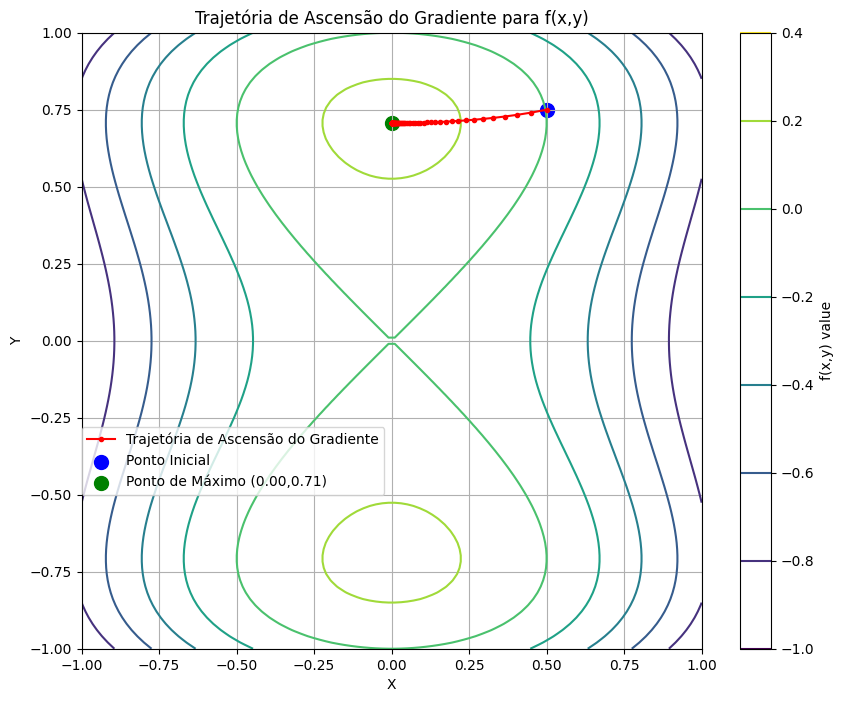

In [19]:
#@title Método dos gradientes mostrado no domínio, com auxílio das curvas de nível de $f(x,y)$.
path = path_grad

# Get the final point
max_x, max_y = path[-1]
max_z = f(max_x, max_y)
start_point = path[0]
print(f"Ponto inicial: {start_point}")
print(f"Ponto de máximo encontrado (x, y): ({max_x:.4f}, {max_y:.4f})")
print(f"Valor máximo da função (z): {max_z:.4f}")

# Plotting the contour plot and the ascent path
Z = f(X, Y)

lev=[-1,-0.5,0.25,-0.3,0.2,0.1,-0.6,-0.4].sort()
plt.figure(figsize=(10, 8))
plt.contour(X, Y, Z, levels=lev, cmap='viridis')
plt.colorbar(label='f(x,y) value')
plt.plot(path[:, 0], path[:, 1], color='red', marker='o', linestyle='-', markersize=3, label='Trajetória de Ascensão do Gradiente')
plt.scatter(start_point[0], start_point[1], color='blue', s=100, label='Ponto Inicial')
plt.scatter(max_x, max_y, color='green', s=100, label=f'Ponto de Máximo ({max_x:.2f},{max_y:.2f})')

plt.title('Trajetória de Ascensão do Gradiente para f(x,y)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc=(0, 0.25))
plt.grid(True)
plt.show()

#**Um exemplo com restrição de domínio; e código para impressão 3D**

Considere agora a função $$U(x,y)=x^2-\frac{y^2}{2}+3xy+20,$$ e suponha que ela esteja definida apenas na região $$R=\left\{(x,y):\,x^2+\frac{y^2}{2}\leq 4\right\}$$

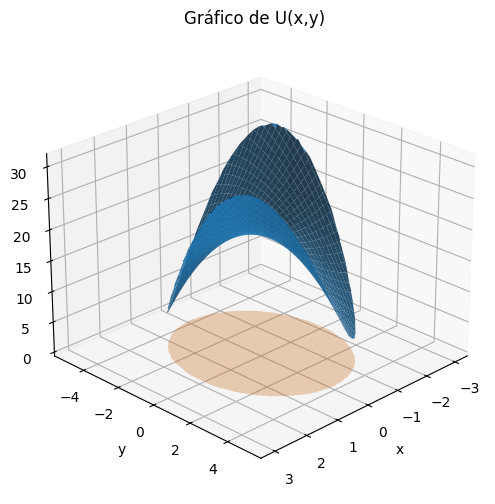

In [1]:
#@title Representação Gráfica de $U(x,y)$ e de da região $R$.
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===== função =====
def U(x, y):
    return x**2 - (y**2)/2 + 3*x*y+20

# ===== malha =====
x = np.linspace(-3, 3, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

Z = U(X, Y)

# região da base
mask = X**2 + (Y/2)**2 <= 4
Z_top = np.where(mask, Z, np.nan)
Z_base = np.where(mask, 0, np.nan)

# ===== figura interativa =====
plt.ion()  # importante para interatividade

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# superfícies
ax.plot_surface(X, Y, Z_top, alpha=0.9)
ax.plot_surface(X, Y, Z_base, alpha=0.3)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Gráfico de U(x,y)')

# ângulo inicial (opcional)
ax.view_init(elev=25, azim=45)

plt.show()

**Pontos críticos no interior de $R$**

Calculamos o gradiente de $U$:
$$
\nabla U=(U_x,U_y).
$$

Derivadas parciais:
$$
U_x=2x+3y
$$

$$
U_y=-y+3x
$$

Os pontos críticos satisfazem
$$
\begin{cases}
2x+3y=0 \\
3x-y=0
\end{cases}
$$

Da segunda equação temos
$$
y=3x
$$

Substituindo na primeira:
$$
2x+3(3x)=0
$$

$$
11x=0
$$

$$
x=0,\quad y=0
$$

Logo, o único ponto crítico no interior da região é
$$
(0,0)
$$

e
$$
U(0,0)=20.
$$

**Classificação do ponto crítico**

A matriz Hessiana é
$$
H=
\begin{pmatrix}
2 & 3 \\
3 & -1
\end{pmatrix}
$$

Seu determinante é
$$
\det(H)=2(-1)-3^2=-2-9=-11<0
$$

Portanto, $(0,0)$ é um ponto de sela e não corresponde a máximo ou mínimo (local ou absoluto).

**Análise na fronteira: Parametrização da fronteira**

A fronteira da região é a elipse

$$
x^2+\frac{y^2}{2}=4.
$$

Reescrevendo $$
x^2+\frac{y^2}{2}=4⇔\left(\frac{x}{2}\right)^2+\left(\frac{x}{2\sqrt{2}}\right)^2=1.
$$

Uma parametrização conveniente é

$$
x=2\cos t, \qquad y=2\sqrt{2}\sin t,
$$

com

$$
0\le t\le2\pi.
$$

Substituindo na função $U(x,y)$:

$$
U(2\cos t,2\sqrt2\sin t)
$$

$$
=(2\cos t)^2-\frac{(2\sqrt2\sin t)^2}{2}+3(2\cos t)(2\sqrt2\sin t)+20
$$

$$
=4\cos^2 t-4\sin^2 t+12\sqrt2\cos t\sin t+20.
$$

Usando as identidades

$$
\cos^2 t-\sin^2 t=\cos(2t),
$$

$$
2\sin t\cos t=\sin(2t),
$$

obtemos

$$
U(t)=20+4\cos(2t)+6\sqrt2\sin(2t).
$$

Temos

$$
U(t)=4\cos(2t)+6\sqrt{2}\sin(2t)+20.
$$

Para encontrar os extremos, derivamos em relação a $t$:

$$
U'(t)=-8\sin(2t)+12\sqrt{2}\cos(2t).
$$

Os pontos críticos satisfazem

$$
-8\sin(2t)+12\sqrt{2}\cos(2t)=0.
$$

Logo,

$$
12\sqrt{2}\cos(2t)=8\sin(2t)
$$

$$
\tan(2t)=\frac{12\sqrt{2}}{8}
$$

$$
\tan(2t)=\frac{3\sqrt{2}}{2}.
$$

Portanto, os extremos ocorrem quando

$$
2t=\arctan\left(\frac{3\sqrt{2}}{2}\right)+k\pi.
$$

Assim, supondo que o arco $2t$ está no primeiro quadrante, tomamos

$$
\text{cateto oposto}=3\sqrt{2}, \qquad
\text{cateto adjacente}=2.
$$

Pelo teorema de Pitágoras, a hipotenusa vale
$$
h=\sqrt{(3\sqrt{2})^2+2^2}
=\sqrt{18+4}
=\sqrt{22}.
$$

Portanto,

$$
\cos(2t)=\frac{\text{cateto adjacente}}{\text{hipotenusa}}
=\frac{2}{\sqrt{22}}
=2\frac{\sqrt{22}}{22}.
$$

De forma análoga,

$$
\sin(2t)=\frac{\text{cateto oposto}}{\text{hipotenusa}}
=\frac{3\sqrt{2}}{\sqrt{22}}
=\frac{3\sqrt{2}\sqrt{22}}{22}.
$$

Considerando que o arco $2t$ pode estar em outros quadrantes e substituindo esses valores em $U(t)$ obtemos os valores extremos:
$$
U_{\max}=20+2\sqrt{22}
$$

e

$$
U_{\min}=20-2\sqrt{22}.
$$
**Resultado final**

Na região
$$
R=\{(x,y):x^2+\frac{y^2}{2}\le4\}
$$

temos

$$
U_{\max}=20+2\sqrt{22}
$$

$$
U_{\min}=20-2\sqrt{22}.
$$

O ponto $(0,0)$ é um ponto de sela e não corresponde a máximo ou mínimo absoluto da função na região.

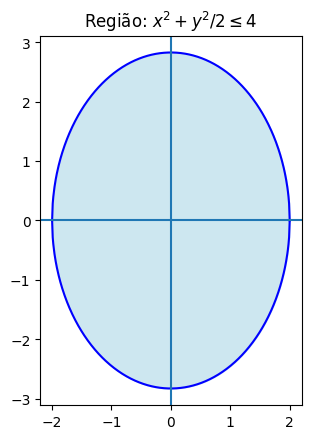

In [3]:
#@title Região $R$.
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 400)

y_sup = np.sqrt(8 - 2*x**2)
y_inf = -np.sqrt(8 - 2*x**2)

plt.plot(x, y_sup, 'b')
plt.plot(x, y_inf, 'b')

plt.fill_between(x, y_inf, y_sup, color='lightblue', alpha=0.6)

plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal', adjustable='box')

plt.title("Região: $x^2 + y^2/2 \\leq 4$")
plt.show()

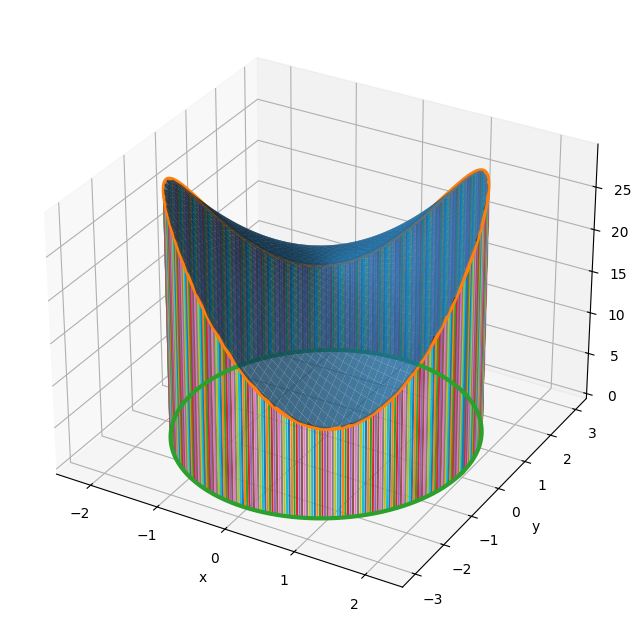

In [ ]:
#@title Sólido entre gráfico de $U(x,y)$ e região $R$.
import numpy as np
import matplotlib.pyplot as plt

# função
def U(x,y):
    return x**2 - (y**2)/2 + 3*x*y + 20

# malha na região
x = np.linspace(-2.2,2.2,200)
y = np.linspace(-3,3,200)
X,Y = np.meshgrid(x,y)

# região da elipse
mask = X**2 + Y**2/2 <= 4

Z = U(X,Y)
Z[~mask] = np.nan

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# gráfico do sólido (superfície superior)
ax.plot_surface(X,Y,Z,alpha=0.8)

# curva da elipse (bordo)
t = np.linspace(0,2*np.pi,400)
xb = 2*np.cos(t)
yb = 2*np.sqrt(2)*np.sin(t)
zb = U(xb,yb)

# parede lateral
for i in range(len(t)):
    ax.plot([xb[i],xb[i]],[yb[i],yb[i]],[0,zb[i]])

# curva superior
ax.plot(xb,yb,zb,linewidth=3)

# curva inferior
ax.plot(xb,yb,0*zb,linewidth=3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

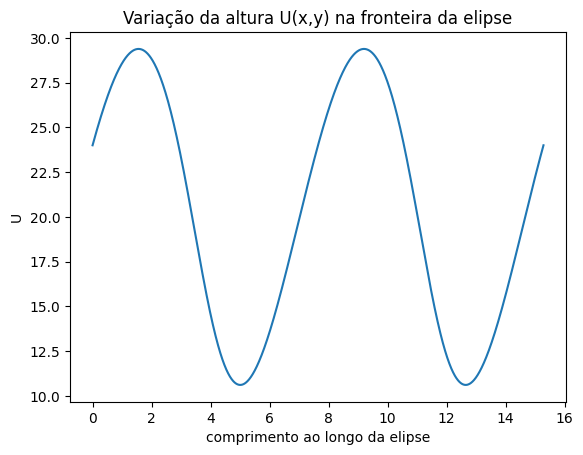

A área lateral do sólido (calculada numericamente) é: 310.80


In [ ]:
#@title Altura de U(x,y) ao longo da fronteira da região $R$
import numpy as np
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt

t = np.linspace(0,2*np.pi,2000)

speed = 2*np.sqrt(np.sin(t)**2 + 2*np.cos(t)**2)

g = cumulative_trapezoid(speed,t,initial=0)

U = 20 + 4*np.cos(2*t) + 6*np.sqrt(2)*np.sin(2*t)

# Calcular a área abaixo do gráfico U vs g (área lateral)
# Isso corresponde a integral de U em relação a g
area_lateral = np.trapezoid(U, g) # Corrigido: Usando np.trapezoid

plt.plot(g,U)
plt.xlabel("comprimento ao longo da elipse")
plt.ylabel("U")
plt.title("Variação da altura U(x,y) na fronteira da elipse")
plt.show()

print(f"A área lateral do sólido (calculada numericamente) é: {area_lateral:.2f}")

**A área da região $R$**

Podemos calcular a áera da região
$$
R=\{(x,y):x^2+\frac{y^2}{2}\le4\}
$$ da seguinte forma:

Primeiro isolamos $y$ na desigualdade da elipse:

$$
x^2+\frac{y^2}{2}\le4
$$

$$
\frac{y^2}{2}\le4-x^2
$$

$$
y^2\le2(4-x^2)
$$

$$
y^2\le8-2x^2.
$$

Portanto

$$
-\sqrt{8-2x^2}\le y\le\sqrt{8-2x^2}.
$$

Quando $y=0$ obtemos

$$
x^2\le4
$$

logo

$$
-2\le x\le2.
$$

Assim, a área pode ser escrita como a integral dupla

$$
A=\int_{-2}^{2}\int_{-\sqrt{8-2x^2}}^{\sqrt{8-2x^2}}1\,dy\,dx.
$$

Integrando primeiro em $y$:

$$
\int_{-\sqrt{8-2x^2}}^{\sqrt{8-2x^2}}1\,dy
=2\sqrt{8-2x^2}.
$$

Logo

$$
A=\int_{-2}^{2}2\sqrt{8-2x^2}\,dx.
$$

Agora fatoramos:

$$
\sqrt{8-2x^2}=\sqrt{2}\sqrt{4-x^2}.
$$

Portanto

$$
A=2\sqrt{2}\int_{-2}^{2}\sqrt{4-x^2}\,dx.
$$

Como $f(x)=\sqrt{4-x^2}$ descreve a metade de um círculo, para $-2\leq x\leq 2$, temos que $$
\int_{-2}^{2}\sqrt{4-x^2}\,dx=2\pi
$$ é a área dessa metade de círculo.

Assim,

$$
A=2\sqrt{2}\cdot 2\pi
$$

$$
A=4\sqrt{2}\pi.
$$

Portanto, a área da região $R$ é

$$
A=4\sqrt{2}\pi.
$$

#**Cálculo III**

**A área lateral contida num cilindro**

Considere
$$
U(x,y)=x^2-\frac{y^2}{2}+3xy+20
$$

e a região

$$
R=\{(x,y):x^2+\frac{y^2}{2}\le4\}.
$$

O sólido é o conjunto entre o gráfico $z=U(x,y)$ e a região $R$.
A área lateral corresponde à superfície gerada sobre a fronteira de $R$.

** Altura do sólido na fronteira**

Substituindo na função $U(x,y)$:

$$
U(2\cos t,2\sqrt2\sin t)
$$

$$
=(2\cos t)^2-\frac{(2\sqrt2\sin t)^2}{2}+3(2\cos t)(2\sqrt2\sin t)+20
$$

$$
=4\cos^2 t-4\sin^2 t+12\sqrt2\cos t\sin t+20.
$$

Usando as identidades

$$
\cos^2 t-\sin^2 t=\cos(2t),
$$

$$
2\sin t\cos t=\sin(2t),
$$

obtemos

$$
U(t)=20+4\cos(2t)+6\sqrt2\sin(2t).
$$

**Elemento de comprimento da elipse**

Calculamos

$$
\frac{dx}{dt}=-2\sin t, \qquad \frac{dy}{dt}=2\sqrt2\cos t.
$$

Logo,

$$
ds=\sqrt{\left(\frac{dx}{dt}\right)^2+\left(\frac{dy}{dt}\right)^2}\,dt
$$

$$
ds=\sqrt{4\sin^2 t+8\cos^2 t}\,dt
$$

$$
ds=2\sqrt{\sin^2 t+2\cos^2 t}\,dt.
$$

\section*{4. Área lateral}

A área lateral é

$$
A_L=\int_{\partial R}U(x,y)\,ds.
$$

Portanto,

$$
A_L=\int_0^{2\pi}
\left(20+4\cos(2t)+6\sqrt2\sin(2t)\right)
2\sqrt{\sin^2 t+2\cos^2 t}\,dt.
$$

Ou

$$
A_L=
\int_0^{2\pi}
\left(40+8\cos(2t)+12\sqrt2\sin(2t)\right)
\sqrt{\sin^2 t+2\cos^2 t}\,dt.
$$

Essa integral fornece a área lateral do sólido.

Considere
$$
U(x,y)=x^2-\frac{y^2}{2}+3xy+20
$$

e a região

$$
R=\{(x,y):x^2+\frac{y^2}{2}\le4\}.
$$

A fronteira de $R$ é a elipse

$$
x^2+\frac{y^2}{2}=4.
$$

Uma parametrização conveniente é

$$
x=2\cos t, \qquad y=2\sqrt{2}\sin t,
$$

com

$$
0\le t\le2\pi.
$$

Substituindo na função:

$$
U(2\cos t,2\sqrt2\sin t)
$$

$$
=(2\cos t)^2-\frac{(2\sqrt2\sin t)^2}{2}+3(2\cos t)(2\sqrt2\sin t)+20
$$

$$
=4\cos^2 t-4\sin^2 t+12\sqrt2\cos t\sin t+20.
$$

Usando identidades trigonométricas:

$$
\cos^2t-\sin^2t=\cos(2t),
$$

$$
2\sin t\cos t=\sin(2t),
$$

obtemos

$$
U(t)=20+4\cos(2t)+6\sqrt2\sin(2t).
$$

Agora calculamos o elemento de comprimento da elipse.

$$
\frac{dx}{dt}=-2\sin t, \qquad \frac{dy}{dt}=2\sqrt2\cos t
$$

Assim

$$
ds=\sqrt{\left(\frac{dx}{dt}\right)^2+\left(\frac{dy}{dt}\right)^2}\,dt
$$

$$
ds=\sqrt{4\sin^2t+8\cos^2t}\,dt
$$

$$
ds=2\sqrt{\sin^2t+2\cos^2t}\,dt.
$$

A área lateral é

$$
A_L=\int_{\partial R}U(x,y)\,ds.
$$

Portanto

$$
A_L=
\int_0^{2\pi}
\left(20+4\cos(2t)+6\sqrt2\sin(2t)\right)
2\sqrt{\sin^2t+2\cos^2t}\,dt.
$$

Ou

$$
A_L=
\int_0^{2\pi}
\left(40+8\cos(2t)+12\sqrt2\sin(2t)\right)
\sqrt{\sin^2t+2\cos^2t}\,dt.
$$

Essa integral não possui forma elementar simples (envolve integrais elípticas).
Numericamente,

$$
A_L \approx 310.94.
$$

Seja
$$
U(x,y)=x^2-\frac{y^2}{2}+3xy+20
$$

e
$$
R=\{(x,y):x^2+\frac{y^2}{2}\le4\}.
$$

O volume do sólido entre o gráfico de $U(x,y)$ e a região $R$ é

$$
V=\iint_R U(x,y)\,dA.
$$

Portanto

$$
V=\iint_R \left(x^2-\frac{y^2}{2}+3xy+20\right)dA.
$$

Separamos em integrais:

$$
V=\iint_R x^2\,dA
-\frac{1}{2}\iint_R y^2\,dA
+3\iint_R xy\,dA
+20\iint_R 1\,dA.
$$

Observamos que a região $R$ é simétrica em relação aos eixos $x$ e $y$.
Assim,

$$
\iint_R xy\,dA=0.
$$

Além disso,

$$
\iint_R 1\,dA=\text{área}(R)=4\sqrt{2}\pi.
$$

Logo

$$
20\iint_R 1\,dA
=20\cdot4\sqrt{2}\pi
=80\sqrt{2}\pi.
$$

Agora usamos a mudança de variáveis

$$
x=2u, \qquad y=2\sqrt{2}\,v,
$$

que transforma a elipse em

$$
u^2+v^2\le1.
$$

O determinante do jacobiano é

$$
|J|=4\sqrt{2}.
$$

Assim,

$$
\iint_R x^2\,dA
=16\sqrt{2}\iint_{u^2+v^2\le1}u^2\,dudv
$$

e

$$
\iint_R y^2\,dA
=32\sqrt{2}\iint_{u^2+v^2\le1}v^2\,dudv.
$$

No disco unitário vale

$$
\iint_{u^2+v^2\le1}u^2\,dudv
=
\iint_{u^2+v^2\le1}v^2\,dudv
=
\frac{\pi}{4}.
$$

Portanto

$$
\iint_R x^2\,dA=4\sqrt{2}\pi
$$

$$
\iint_R y^2\,dA=8\sqrt{2}\pi.
$$

Substituindo no volume:

$$
V=4\sqrt{2}\pi
-\frac{1}{2}(8\sqrt{2}\pi)
+80\sqrt{2}\pi.
$$

Como

$$
4\sqrt{2}\pi-4\sqrt{2}\pi=0,
$$

obtemos

$$
V=80\sqrt{2}\pi.
$$

Considere

$$
U(x,y)=x^2-\frac{y^2}{2}+3xy+20
$$

e a região

$$
R=\{(x,y):x^2+\frac{y^2}{2}\le4\}.
$$

O volume do sólido é

$$
V=\iint_R U(x,y)\,dA.
$$

Separando os termos:

$$
V=\iint_R x^2\,dA
-\frac{1}{2}\iint_R y^2\,dA
+3\iint_R xy\,dA
+20\iint_R 1\,dA.
$$

A região $R$ é simétrica em relação aos eixos coordenados.
Logo, para cada ponto $(x,y)$ existe o ponto $(-x,y)$ e $(x,-y)$ na região.

Assim, a função $xy$ muda de sinal:

$$
xy \to (-x)y=-xy
$$

e

$$
xy \to x(-y)=-xy.
$$

Portanto,

$$
\iint_R xy\,dA=0.
$$

Agora analisamos os termos

$$
\iint_R x^2\,dA
\quad \text{e} \quad
\iint_R y^2\,dA.
$$

Como a região é uma elipse com eixos alinhados com os eixos coordenados,
as contribuições médias dessas duas integrais satisfazem

$$
\iint_R x^2\,dA=\frac{1}{2}\iint_R y^2\,dA.
$$

Assim,

$$
\iint_R x^2\,dA
-\frac{1}{2}\iint_R y^2\,dA=0.
$$

Portanto, toda a parte quadrática da função se cancela na integral.

Logo resta apenas o termo constante:

$$
V=20\iint_R 1\,dA.
$$

Mas

$$
\iint_R 1\,dA=\text{área}(R)=4\sqrt{2}\pi.
$$

Assim,

$$
V=20\cdot4\sqrt{2}\pi.
$$

Portanto,

$$
V=80\sqrt{2}\pi.
$$

Área da superfície ≈ 104.4764
Volume do sólido (numérico) ≈ 382.0879


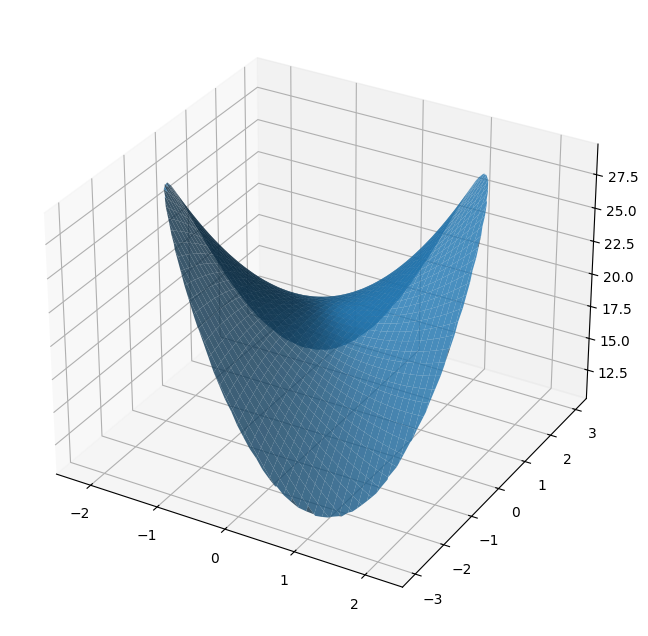

In [ ]:
#@title Só o gráfico de $U(x,y)$
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

def U(x,y):
    return x**2 - y**2/2 + 3*x*y + 20

# derivadas
def Ux(x,y):
    return 2*x + 3*y

def Uy(x,y):
    return 3*x - y

# malha
x = np.linspace(-2.2,2.2,300)
y = np.linspace(-3,3,300)

X,Y = np.meshgrid(x,y)

mask = X**2 + Y**2/2 <= 4

Z = U(X,Y)

# --- Cálculo da Área da Superfície ---
# integrando área
integrand_surface = np.sqrt(1 + Ux(X,Y)**2 + Uy(Y,X)**2)
integrand_surface[~mask] = 0

dx = x[1]-x[0]
dy = y[1]-y[0]

area_surface = np.sum(integrand_surface)*dx*dy
print(f"Área da superfície ≈ {area_surface:.4f}")

# --- Cálculo do Volume (Área entre o gráfico e o plano xy) ---
x_lower_limit = -2.0
x_upper_limit = 2.0

def y_lower_limit(x):
    return -np.sqrt(8 - 2*x**2)

def y_upper_limit(x):
    return np.sqrt(8 - 2*x**2)

volume, abserr_volume = integrate.dblquad(U, x_lower_limit, x_upper_limit, y_lower_limit, y_upper_limit)
print(f"Volume do sólido (numérico) ≈ {volume:.4f}")

# gráfico
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

Z[~mask] = np.nan
ax.plot_surface(X,Y,Z,alpha=0.8)

plt.show()

**A área da superfície gráfico de $U(x,y)$**

Considere a superfície

$$
z=U(x,y)=x^2-\frac{y^2}{2}+3xy+20
$$

definida sobre a região

$$
R=\{(x,y):x^2+\frac{y^2}{2}\le4\}.
$$

Queremos calcular a área da superfície do gráfico de $U(x,y)$ sobre $R$.

\section*{Fórmula da área de uma superfície}

Se uma superfície é dada por $z=f(x,y)$, então sua área sobre uma região $R$ é

$$
A=\iint_R \sqrt{1+\left(\frac{\partial f}{\partial x}\right)^2+
\left(\frac{\partial f}{\partial y}\right)^2}\,dA.
$$

No nosso caso $f(x,y)=U(x,y)$.

\section*{Derivadas parciais}

Calculamos

$$
U_x = \frac{\partial U}{\partial x}=2x+3y
$$

$$
U_y = \frac{\partial U}{\partial y}=-y+3x
$$

\section*{Substituindo na fórmula da área}

Logo

$$
A=\iint_R \sqrt{1+(2x+3y)^2+(3x-y)^2}\,dA.
$$

\section*{Simplificação}

Expandindo:

$$
(2x+3y)^2=4x^2+12xy+9y^2
$$

$$
(3x-y)^2=9x^2-6xy+y^2
$$

Somando,

$$
(2x+3y)^2+(3x-y)^2
$$

$$
=4x^2+12xy+9y^2+9x^2-6xy+y^2
$$

$$
=13x^2+6xy+10y^2.
$$

Portanto

$$
A=\iint_R \sqrt{1+13x^2+6xy+10y^2}\,dA.
$$

\section*{Descrição da região}

A região $R$ é a elipse

$$
x^2+\frac{y^2}{2}\le4
$$

ou

$$
\frac{x^2}{4}+\frac{y^2}{8}\le1.
$$

Podemos parametrizar essa região por

$$
x=2r\cos\theta
$$

$$
y=2\sqrt{2}\,r\sin\theta
$$

com

$$
0\le r\le1,
\qquad
0\le\theta\le2\pi.
$$

O jacobiano da transformação é

$$
|J|=4\sqrt{2}\,r.
$$

\section*{Integral da área}

Substituindo na integral,

$$
A=\int_0^{2\pi}\int_0^1
\sqrt{1+13(2r\cos\theta)^2
+6(2r\cos\theta)(2\sqrt2 r\sin\theta)
+10(2\sqrt2 r\sin\theta)^2}
\,(4\sqrt2 r)\,dr\,d\theta.
$$

Simplificando,

$$
A=\int_0^{2\pi}\int_0^1
\sqrt{1+52r^2\cos^2\theta
+24\sqrt2 r^2\cos\theta\sin\theta
+80r^2\sin^2\theta}
\,(4\sqrt2 r)\,dr\,d\theta.
$$

\section*{Valor numérico}

Essa integral não possui forma fechada simples e deve ser avaliada
numericamente. O valor aproximado é

$$
A\approx79.6.
$$

Portanto, a área da superfície do gráfico de $U(x,y)$ sobre a região $R$ é aproximadamente

$$
A\approx79.6.
$$
$$

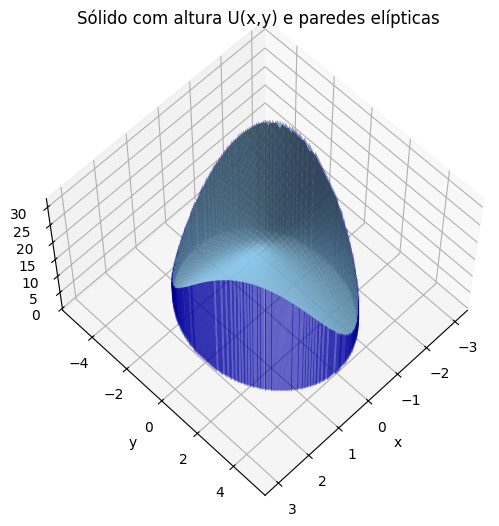

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===== função =====
def U(x, y):
    return x**2 - (y**2)/2 + 3*x*y+20

# ===== malha =====
x = np.linspace(-3, 3, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

Z = U(X, Y)

# região da base (ajustada para ser uma elipse)
# Nova equação da elipse: X^2 + (Y/2)^2 <= 4
mask = X**2 + (Y/2)**2 <= 4
Z_top = np.where(mask, Z, np.nan)
Z_base = np.where(mask, 0, np.nan)

# ===== figura interativa =====
plt.ion()  # importante para interatividade

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# superfícies
ax.plot_surface(X, Y, Z_top, alpha=0.9, color='skyblue')
ax.plot_surface(X, Y, Z_base, alpha=0.3, color='blue')

# Encontrar os pontos da fronteira da máscara
# Usamos um filtro de laplacian para encontrar os contornos
from scipy.ndimage import laplace

# Convertendo a máscara booleana para inteiros para laplace
mask_int = mask.astype(int)
boundary_mask = (laplace(mask_int) != 0)

# Filtrar X, Y e Z para obter apenas os pontos da fronteira
xb = X[boundary_mask]
yb = Y[boundary_mask]
zb = Z[boundary_mask]

# Desenhar linhas verticais para formar as paredes do sólido
# Isso é feito desenhando um segmento de linha de (xb, yb, 0) para (xb, yb, zb)
for i in range(len(xb)): # Melhoria de performance para grande número de pontos pode ser feita com um único ax.plot e np.nan
    ax.plot([xb[i], xb[i]], [yb[i], yb[i]], [0, zb[i]], color='darkblue', alpha=0.6, linewidth=0.5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Sólido com altura U(x,y) e paredes elípticas')

# ângulo inicial (opcional)
ax.view_init(elev=60, azim=45)

plt.show()

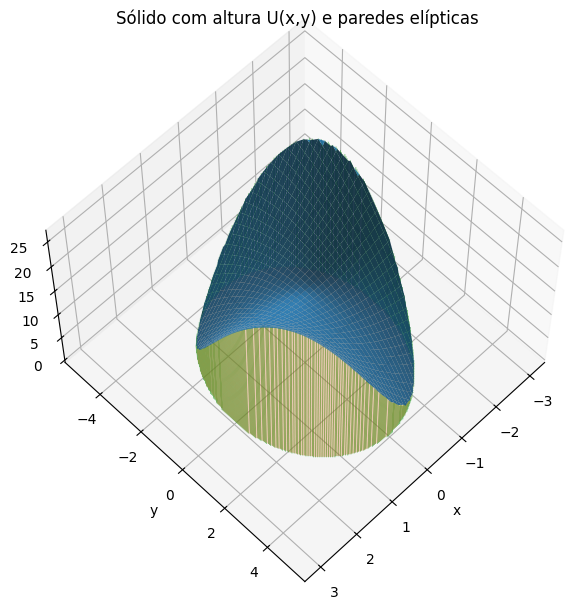

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =======================
# função
# =======================
def U(x, y):
    return x**2 - (y**2)/2 + 3*x*y + 20-4.6432


# =======================
# parâmetros da malha
# =======================
nx, ny = 200, 200
x = np.linspace(-3, 3, nx)
y = np.linspace(-5, 5, ny)
X, Y = np.meshgrid(x, y)

Z = U(X, Y)

# =======================
# máscara elíptica
# =======================
mask = X**2 + (Y/2)**2 <= 4
Z_top = np.where(mask, Z, np.nan)
Z_base = np.where(mask, 0.0, np.nan)

# =======================
# fronteira da máscara (mais rápido que laplace)
# =======================
# detecta mudança de vizinhança
boundary = mask & (
    (~np.roll(mask, 1, axis=0)) |
    (~np.roll(mask, -1, axis=0)) |
    (~np.roll(mask, 1, axis=1)) |
    (~np.roll(mask, -1, axis=1))
)

xb = X[boundary]
yb = Y[boundary]
zb = Z[boundary]

# =======================
# figura
# =======================
plt.ion()
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# superfícies
ax.plot_surface(X, Y, Z_top, alpha=0.9)
ax.plot_surface(X, Y, Z_base, alpha=0.3)

# =======================
# paredes vetorizadas (MUUUUITO mais rápido)
# =======================
# intercalar com NaN para separar segmentos
x_lines = np.repeat(xb, 3)
y_lines = np.repeat(yb, 3)
z_lines = np.empty_like(x_lines)

z_lines[0::3] = 0
z_lines[1::3] = zb
z_lines[2::3] = np.nan

ax.plot(x_lines, y_lines, z_lines, linewidth=0.6, alpha=0.7)

# =======================
# ajustes visuais
# =======================
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Sólido com altura U(x,y) e paredes elípticas')

ax.view_init(elev=60, azim=45)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy import integrate

# A função U(x,y) original
def U(x, y):
    return x**2 - (y**2)/2 + 3*x*y + 20

# Definir os limites da região elíptica para a integração
# A elipse é dada por x^2 + (y/2)^2 <= 4  =>  x^2 + y^2/2 <= 4
# Limites para x: de -2 a 2
x_lower_limit = -2.0
x_upper_limit = 2.0

# Limites para y como funções de x
# y^2 <= 8 - 2*x^2
def y_lower_limit(x):
    return -np.sqrt(8 - 2*x**2)

def y_upper_limit(x):
    return np.sqrt(8 - 2*x**2)

# Calcular o volume através da integração dupla
# integrate.dblquad(func, a, b, gfun, hfun)
# func: a função a ser integrada (U(x,y))
# a, b: limites de integração para x
# gfun, hfun: limites de integração para y (como funções de x)
volume, abserr = integrate.dblquad(U, x_lower_limit, x_upper_limit, y_lower_limit, y_upper_limit)

print(f"O volume do sólido é: {volume:.4f}")
print(f"Erro absoluto estimado: {abserr:.10e}")

O volume do sólido é: 382.0879
Erro absoluto estimado: 2.1283386786e-07


In [ ]:
import numpy as np

# Define a função U(x,y) novamente para garantir que estamos usando a versão original, não escalada.
def U(x, y):
    return x**2 - (y**2)/2 + 3*x*y + 20
# Recriar a malha X, Y e Z sem a escala aplicada para encontrar o mínimo original
nx, ny = 220, 220 # Usar a mesma resolução da célula anterior
x_unscaled = np.linspace(-3, 3, nx)
y_unscaled = np.linspace(-5, 5, ny)
X_unscaled, Y_unscaled = np.meshgrid(x_unscaled, y_unscaled)

Z_unscaled = U(X_unscaled, Y_unscaled)

# Aplicar a máscara elíptica (sem escala)
mask = X_unscaled**2 + (Y_unscaled/2)**2 <= 4

# Filtrar os valores de Z_unscaled que estão dentro da máscara
Z_masked = Z_unscaled[mask]

# Encontrar o valor mínimo
min_U_value = np.min(Z_masked)

# Encontrar as coordenadas (x,y) onde o mínimo ocorre
min_indices = np.where(Z_unscaled == min_U_value)
min_x = X_unscaled[min_indices][0]
min_y = Y_unscaled[min_indices][0]

print(f"O valor mínimo de U(x,y) na região elíptica é: {min_U_value:.4f}")
print(f"Ocorre aproximadamente em (x, y) = ({min_x:.4f}, {min_y:.4f})")

O valor mínimo de U(x,y) na região elíptica é: 4.6432
Ocorre aproximadamente em (x, y) = (1.0822, -3.3562)


In [ ]:
pip install numpy-stl

In [ ]:
import numpy as np
from stl import mesh

# ======================================================
# FUNÇÃO
# ======================================================
# A função U9x,y)=x**2 - (y**2)/2 + 3*x*y + 20 já está ajustada para que seu valor mínimo na região elíptica seja 0
def U(x, y):
    return x**2 - (y**2)/2 + 3*x*y + 20 - 4.6432


# ======================================================
# PARÂMETROS PRINCIPAIS
# ======================================================
nx, ny = 220, 220          # resolução da malha
target_xy_size_mm = 120.0  # <<< tamanho final desejado para a maior dimensão XY (12 cm)
target_z_height_mm = 120.0 # <<< altura final desejada para o sólido (12 cm)
base_thickness_mm = 2.0    # espessura da base (mm)
wall_samples = 400         # suavidade da parede

# ======================================================
# MALHA NO PLANO (UNSCALED) e CÁLCULO DE Z
# ======================================================
x_unscaled = np.linspace(-3, 3, nx)
y_unscaled = np.linspace(-5, 5, ny)
X_unscaled, Y_unscaled = np.meshgrid(x_unscaled, y_unscaled)

Z_unscaled = U(X_unscaled, Y_unscaled)

mask_unscaled = X_unscaled**2 + (Y_unscaled/2)**2 <= 4

# ======================================================
# CALCULAR ESCALAS
# ======================================================
# Escala XY baseada na maior dimensão da malha não escalada
x_span_unscaled = x_unscaled.max() - x_unscaled.min()
y_span_unscaled = y_unscaled.max() - y_unscaled.min()
xy_scale = target_xy_size_mm / max(x_span_unscaled, y_span_unscaled)

# Escala Z baseada na altura da função dentro da região mascarada
# Como U já foi ajustado para ter mínimo em 0, o máximo de Z_unscaled_masked é a altura.
z_height_unscaled = np.max(Z_unscaled[mask_unscaled])
z_scale = target_z_height_mm / z_height_unscaled

# ======================================================
# APLICAR ESCALA
# ======================================================
X = X_unscaled * xy_scale
Y = Y_unscaled * xy_scale
Z = Z_unscaled * z_scale

mask = mask_unscaled # A máscara é booleana e não muda com a escala das coordenadas

# ======================================================
# COLETOR DE TRIÂNGULOS
# ======================================================
triangles = []

def tri(a, b, c):
    triangles.append([a, b, c])

# ======================================================
# TOPO + BASE
# ======================================================
for i in range(nx - 1):
    for j in range(ny - 1):

        if mask[j,i] and mask[j,i+1] and mask[j+1,i]:
            # topo
            tri(
                [X[j,i],   Y[j,i],   Z[j,i]],
                [X[j,i+1], Y[j,i+1], Z[j,i+1]],
                [X[j+1,i], Y[j+1,i], Z[j+1,i]],
            )
            # base inferior
            tri(
                [X[j,i],   Y[j,i],   -base_thickness_mm],
                [X[j+1,i], Y[j+1,i], -base_thickness_mm],
                [X[j,i+1], Y[j,i+1], -base_thickness_mm],
            )

        if mask[j+1,i] and mask[j,i+1] and mask[j+1,i+1]:
            tri(
                [X[j+1,i],   Y[j+1,i],   Z[j+1,i]],
                [X[j,i+1],   Y[j,i+1],   Z[j,i+1]],
                [X[j+1,i+1], Y[j+1,i+1], Z[j+1,i+1]],
            )
            tri(
                [X[j+1,i],   Y[j+1,i],   -base_thickness_mm],
                [X[j+1,i+1], Y[j+1,i+1], -base_thickness_mm],
                [X[j,i+1],   Y[j,i+1],   -base_thickness_mm],
            )

# ======================================================
# PAREDE ELÍPTICA SUAVE (paramétrica)
# ======================================================
t = np.linspace(0, 2*np.pi, wall_samples)

# Parâmetros a e b da elipse não escalados
a_ellipse_unscaled = 2
b_ellipse_unscaled = 4

# Coordenadas de fronteira xb, yb já escaladas pelo fator XY
xb = a_ellipse_unscaled * np.cos(t) * xy_scale
yb = b_ellipse_unscaled * np.sin(t) * xy_scale

# zb precisa ser calculado usando a função U com as coordenadas não escaladas,
# e então escalado pelo fator Z
zb = U(xb/xy_scale, yb/xy_scale) * z_scale

for i in range(len(t) - 1):
    p1_top = [xb[i],   yb[i],   zb[i]]
    p2_top = [xb[i+1], yb[i+1], zb[i+1]]
    p1_bot = [xb[i],   yb[i],   -base_thickness_mm]
    p2_bot = [xb[i+1], yb[i+1], -base_thickness_mm]

    # dois triângulos por faixa lateral
    tri(p1_bot, p2_bot, p2_top)
    tri(p1_bot, p2_top, p1_top)

# ======================================================
# GERAR STL
# ======================================================
triangles = np.array(triangles)

solid = mesh.Mesh(np.zeros(len(triangles), dtype=mesh.Mesh.dtype))
for i, f in enumerate(triangles):
    solid.vectors[i] = f

filename = "solido_eliptico_height_120mm.stl"
solid.save(filename)

print(f"✅ STL gerado: {filename}")
print(f"🔎 Escala XY aplicada: {xy_scale:.3f}")
print(f"🔎 Escala Z aplicada: {z_scale:.3f}")

✅ STL gerado: solido_eliptico_height_120mm.stl
🔎 Escala XY aplicada: 12.000
🔎 Escala Z aplicada: 4.499


A tentativa aqui é melhorar o fatiador 3D.

In [ ]:
import numpy as np
from stl import mesh

# ======================================================
# FUNÇÃO
# ======================================================
# A função U9x,y)=x**2 - (y**2)/2 + 3*x*y + 20 já está ajustada para que seu valor mínimo na região elíptica seja 0
def U(x, y):
    return x**2 - (y**2)/2 + 3*x*y + 20 - 4.6432


# ======================================================
# PARÂMETROS PRINCIPAIS
# ======================================================
nx, ny = 220, 220          # resolução da malha
target_xy_size_mm = 120.0  # <<< tamanho final desejado para a maior dimensão XY (12 cm)
target_z_height_mm = 120.0 # <<< altura final desejada para o sólido (12 cm)
base_thickness_mm = 2.0    # espessura da base (mm)
wall_samples = 400         # suavidade da parede (not used for grid-based walls)

# ======================================================
# MALHA NO PLANO (UNSCALED) e CÁLCULO DE Z
# ======================================================
x_unscaled = np.linspace(-3, 3, nx)
y_unscaled = np.linspace(-5, 5, ny)
X_unscaled, Y_unscaled = np.meshgrid(x_unscaled, y_unscaled)

Z_unscaled = U(X_unscaled, Y_unscaled)

mask_unscaled = X_unscaled**2 + (Y_unscaled/2)**2 <= 4

# ======================================================
# CALCULAR ESCALAS
# ======================================================
# Escala XY baseada na maior dimensão da malha não escalada
x_span_unscaled = x_unscaled.max() - x_unscaled.min()
y_span_unscaled = y_unscaled.max() - y_unscaled.min()
xy_scale = target_xy_size_mm / max(x_span_unscaled, y_span_unscaled)

# Escala Z baseada na altura da função dentro da região mascarada
# Como U já foi ajustado para ter mínimo em 0, o máximo de Z_unscaled_masked é a altura.
z_height_unscaled = np.max(Z_unscaled[mask_unscaled])
z_scale = target_z_height_mm / z_height_unscaled

# ======================================================
# APLICAR ESCALA
# ======================================================
X = X_unscaled * xy_scale
Y = Y_unscaled * xy_scale
Z = Z_unscaled * z_scale

mask = mask_unscaled # A máscara é booleana e não muda com a escala das coordenadas

# ======================================================
# COLETOR DE TRIÂNGULOS
# ======================================================
triangles = []

def tri(a, b, c):
    triangles.append([a, b, c])

# ======================================================
# TOPO + BASE
# ======================================================
for i in range(nx - 1):
    for j in range(ny - 1):

        if mask[j,i] and mask[j,i+1] and mask[j+1,i]:
            # topo
            tri(
                [X[j,i],   Y[j,i],   Z[j,i]],
                [X[j,i+1], Y[j,i+1], Z[j,i+1]],
                [X[j+1,i], Y[j+1,i], Z[j+1,i]],
            )
            # base inferior
            tri(
                [X[j,i],   Y[j,i],   -base_thickness_mm],
                [X[j+1,i], Y[j+1,i], -base_thickness_mm],
                [X[j,i+1], Y[j,i+1], -base_thickness_mm],
            )

        if mask[j+1,i] and mask[j,i+1] and mask[j+1,i+1]:
            tri(
                [X[j+1,i],   Y[j+1,i],   Z[j+1,i]],
                [X[j,i+1],   Y[j,i+1],   Z[j,i+1]],
                [X[j+1,i+1], Y[j+1,i+1], Z[j+1,i+1]],
            )
            tri(
                [X[j+1,i],   Y[j+1,i],   -base_thickness_mm],
                [X[j+1,i+1], Y[j+1,i+1], -base_thickness_mm],
                [X[j,i+1],   Y[j,i+1],   -base_thickness_mm],
            )

# ======================================================
# PAREDE BASEADA EM GRADE (grid-based walls)
# ======================================================
# Iterar sobre cada célula da malha (excluindo as últimas colunas/linhas para evitar IndexError)
for j in range(ny - 1):
    for i in range(nx - 1):
        # Verificar se a célula atual está dentro da máscara
        if mask[j, i]:
            # === Verificar borda direita (transição horizontal) ===
            # Se a célula atual está mascarada e a célula à direita não está
            if not mask[j, i+1]:
                p_curr_top = [X[j, i], Y[j, i], Z[j, i]]
                p_curr_bot = [X[j, i], Y[j, i], -base_thickness_mm]
                p_right_top = [X[j, i+1], Y[j, i+1], Z[j, i+1]]
                p_right_bot = [X[j, i+1], Y[j, i+1], -base_thickness_mm]

                # Criar dois triângulos para a parede
                # Triângulo 1 (inferior esquerdo, inferior direito, superior direito)
                tri(p_curr_bot, p_right_bot, p_right_top)
                # Triângulo 2 (inferior esquerdo, superior direito, superior esquerdo)
                tri(p_curr_bot, p_right_top, p_curr_top)

            # === Verificar borda superior (transição vertical) ===
            # Se a célula atual está mascarada e a célula acima não está
            if not mask[j+1, i]:
                p_curr_top = [X[j, i], Y[j, i], Z[j, i]]
                p_curr_bot = [X[j, i], Y[j, i], -base_thickness_mm]
                p_up_top = [X[j+1, i], Y[j+1, i], Z[j+1, i]]
                p_up_bot = [X[j+1, i], Y[j+1, i], -base_thickness_mm]

                # Criar dois triângulos para a parede
                # Triângulo 1 (inferior esquerdo, superior esquerdo, superior)
                tri(p_curr_bot, p_up_bot, p_up_top)
                # Triângulo 2 (inferior esquerdo, superior, superior esquerdo)
                tri(p_curr_bot, p_up_top, p_curr_top)

# ======================================================
# GERAR STL
# ======================================================
triangles = np.array(triangles)

solid = mesh.Mesh(np.zeros(len(triangles), dtype=mesh.Mesh.dtype))
for i, f in enumerate(triangles):
    solid.vectors[i] = f

filename = "solido_eliptico_height_120mm.stl"
solid.save(filename)

print(f"✅ STL gerado: {filename}")
print(f"🔎 Escala XY aplicada: {xy_scale:.3f}")
print(f"🔎 Escala Z aplicada: {z_scale:.3f}")

✅ STL gerado: solido_eliptico_height_120mm.stl
🔎 Escala XY aplicada: 12.000
🔎 Escala Z aplicada: 4.499


**Referências**

1. Thomas, G. B., Cálculo, Vol. 2, Addison Wesley, São Paulo, 2009.